# PV support in Europe — two-panel map

**Panel a** — support scheme per country (feed-in tariff/premium, investment subsidy, both, none, not considered).  
**Panel b** — level of feed-in support per country, shown as the discounted coverage of investment costs (%) at each country point.

All inputs are read from **`pv_support_data.csv`**; geometries from the **`world-administrative-boundaries`** shapefile. Label positions are derived from the geometries themselves (representative interior point), so no separate points file is needed.

The notebook also reproduces the derivation of the **~56% coverage** that underlies the 60% support level used in the study.

In [1]:
# %pip install geopandas pandas matplotlib   # if needed

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# CONFIG — adjust paths to your machine
BASE     = r'C:\Users\delic\E2M2s-discounting\0) GitHub\Supplementary material\1) Support strucutre'
SHP_PATH = os.path.join(BASE, 'world-administrative-boundaries.shp')
CSV_PATH = os.path.join(BASE, 'pv_support_data.csv')

ISO_COL  = 'iso_3166_1_'   # ISO 3166-1 alpha-2 column in the shapefile attribute table
EXTENT   = [-11, 32, 34, 72]   # lon_min, lon_max, lat_min, lat_max

# Assumptions for the feed-in coverage calculation
SELF_CONSUMPTION = 0.40    # share of generation self-consumed (not remunerated by the FiT)
DISCOUNT_RATE    = 0.15    # implicit household discount rate (De Groote & Verboven, 2019)
INV_COST_2024    = 853.89  # common 2024 rooftop-PV investment cost (€/kWp) for the average

In [3]:
# 1) Raw support data

df = pd.read_csv(CSV_PATH)

def categorise(r):
    if r['feed_in_tariff'] and r['investment_grant']: return 'Both subsidies'
    if r['feed_in_tariff']:                           return 'Feed-in tariff/premium'
    if r['investment_grant']:                         return 'Investment subsidy'
    return 'No subsidy'
df['category'] = df.apply(categorise, axis=1)
df.head()

,code,country,feed_in_tariff,investment_grant,fit_ct_per_kwh,guarantee_years,fullload_hours,investment_cost_eur_per_kwp,fit_source,investment_grant_source,category
0,AL,Albania,1,0,9.72,15.0,1140.7,548.83,https://www.energy-community.org/dam/jcr:3f7e7...,NaN,Feed-in tariff/premium
1,AT,Austria,1,1,18.12,13.0,1111.9,842.39,https://www.oem-ag.at/de/oekostromneu/einspeis...,https://www.ris.bka.gv.at/GeltendeFassung.wxe?...,Both subsidies
2,BA,Bosnia and Herzegovina,1,0,15.93,12.0,1270.7,529.45,https://www.oieiek.ba/garantovane-i-referentne...,NaN,Feed-in tariff/premium
3,BE,Belgium,1,1,8.50,15.0,989.3,853.89,https://www.energyprice.be/blog/photovoltaic-p...,https://www.pv-magazine.com/2023/04/20/belgium...,Both subsidies
4,BG,Bulgaria,1,1,10.68,20.0,1258.2,517.86,https://www.dker.bg/uploads/reshenia/2023/res_...,https://www.enpal.de/photovoltaik/foerderung,Both subsidies


## Deriving the ~56% feed-in coverage

For every country with a feed-in tariff we compute the annual payment per kWp as the grid-fed share of generation (full-load hours × tariff × (1 − self-consumption)), discount it over the guarantee period at the implicit household rate of 15%, and relate the resulting net present value to investment costs.

- **Per-country coverage** uses each country’s own investment cost → a highly heterogeneous picture (roughly 10% to >100%, i.e. some tariffs overcompensate).
- The **cross-country average for a 2024 investment** uses a common 2024 rooftop-PV cost and yields about **56%**, which is rounded up to the **60%** support level used in the model.

In [4]:
# 2) Feed-in NPV and coverage

def feedin_npv(flh, tariff_ct, years, sc=SELF_CONSUMPTION, ir=DISCOUNT_RATE):
    '''Discounted NPV of feed-in payments per kWp (constant payment over the guarantee period).'''
    if pd.isna(flh) or pd.isna(tariff_ct) or pd.isna(years):
        return np.nan
    annual = flh * (tariff_ct / 100.0) * (1 - sc)          # €/kWp per year, grid-fed share only
    return sum(annual / (1 + ir) ** t for t in range(1, int(years) + 1))

df['fit_npv_eur_per_kwp'] = df.apply(
    lambda r: feedin_npv(r['fullload_hours'], r['fit_ct_per_kwh'], r['guarantee_years']), axis=1)

# per-country coverage (own investment cost) — shows the heterogeneity
df['coverage_own'] = df['fit_npv_eur_per_kwp'] / df['investment_cost_eur_per_kwp']

# cross-country average coverage for a common 2024 investment cost
avg_coverage_2024 = df['fit_npv_eur_per_kwp'].mean() / INV_COST_2024
print(f'Per-country coverage (own cost): '
      f"{df['coverage_own'].min()*100:.0f}% to {df['coverage_own'].max()*100:.0f}%")
print(f'Average coverage for a 2024 investment: {avg_coverage_2024*100:.1f}%  -> rounded to 60%')

Per-country coverage (own cost): 7% to 143%
Average coverage for a 2024 investment: 55.2%  -> rounded to 60%


In [5]:
# 3) Geometries + merge

gdf = gpd.read_file(SHP_PATH)
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
gdf = gdf.rename(columns={ISO_COL: 'code'})

# dissolve multipart countries so each code is a single feature, then merge support data
gdf = gdf.dissolve(by='code').reset_index()
geo = gdf.merge(df, on='code', how='left')

# interior label points (no external points file needed)
reps = geo.representative_point()
geo['lon'] = reps.x
geo['lat'] = reps.y

in_scope = geo[geo['country'].notna()]
print('countries with support data on the map:', len(in_scope))

countries with support data on the map: 33


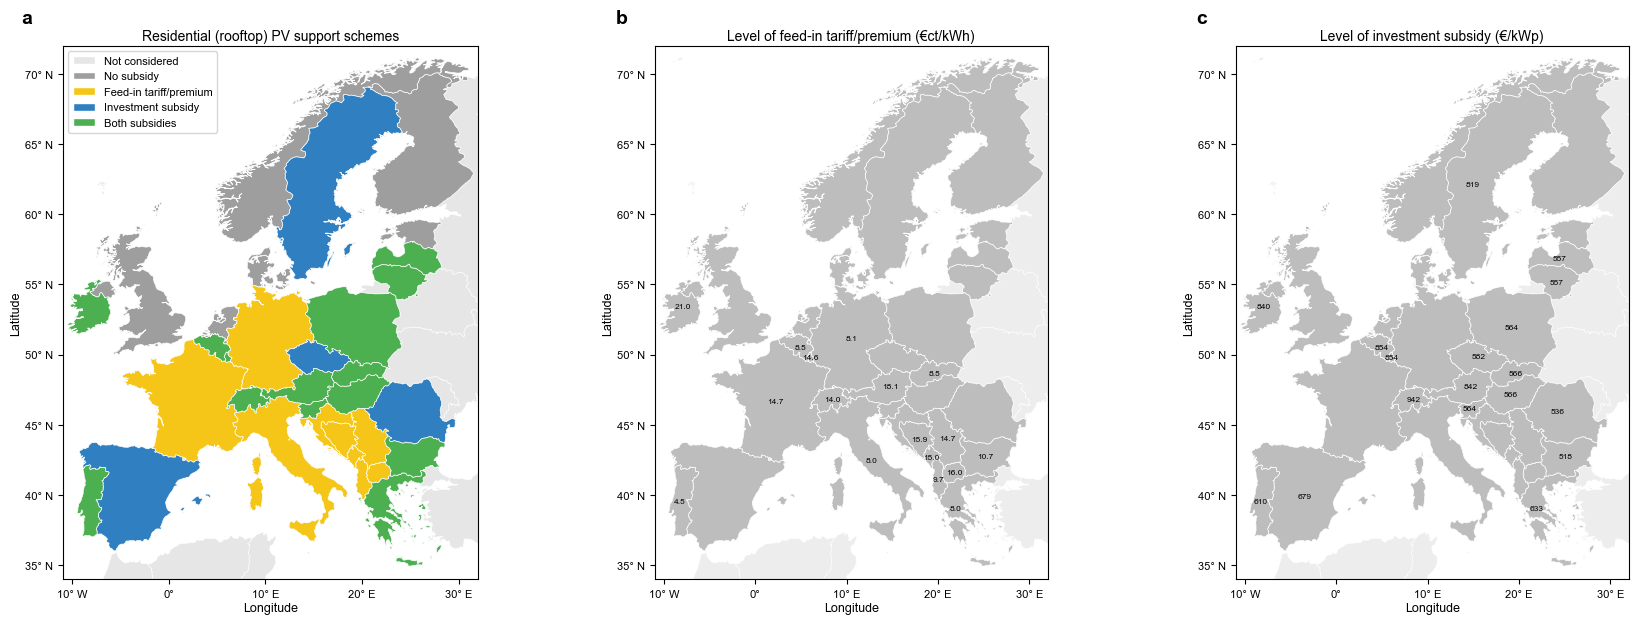

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter, MultipleLocator


CAT_COLORS = {
    "No subsidy": "#9e9e9e",
    "Feed-in tariff/premium": "#f5c518",
    "Investment subsidy": "#2f7fc1",
    "Both subsidies": "#4caf50",
}

NOT_CONSIDERED = "#e6e6e6"
B_NOT_CONSIDERED = "#ededed"
B_CONSIDERED = "#bdbdbd"


def format_lon(x, _pos):
    if abs(x) < 1e-9:
        return "0°"
    direction = "E" if x > 0 else "W"
    return f"{abs(x):.0f}° {direction}"


def format_lat(y, _pos):
    if abs(y) < 1e-9:
        return "0°"
    direction = "N" if y > 0 else "S"
    return f"{abs(y):.0f}° {direction}"


def setup_map_axis(ax):
    ax.set_xlim(EXTENT[0], EXTENT[1])
    ax.set_ylim(EXTENT[2], EXTENT[3])

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(5))

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

    ax.set_xlabel("Longitude", labelpad=2)
    ax.set_ylabel("Latitude", labelpad=2)
    ax.tick_params(axis="both", labelsize=8)


def add_panel_label(ax, label):
    ax.text(
        -0.10,
        1.035,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="left",
    )


def plot_background(ax, color):
    gdf.plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )


plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(18, 6.2))
fig.subplots_adjust(
    left=0.04,
    right=0.99,
    bottom=0.08,
    top=0.94,
    wspace=0.06,
)

for ax in (axa, axb, axc):
    setup_map_axis(ax)


plot_background(axa, NOT_CONSIDERED)

for category, color in CAT_COLORS.items():
    subset = geo[geo["category"] == category]
    if not subset.empty:
        subset.plot(
            ax=axa,
            color=color,
            edgecolor="white",
            linewidth=0.5,
        )

legend_handles = [
    mpatches.Patch(
        facecolor=NOT_CONSIDERED,
        edgecolor="white",
        label="Not considered",
    )
]

legend_handles.extend(
    mpatches.Patch(
        facecolor=CAT_COLORS[category],
        edgecolor="white",
        label=category,
    )
    for category in [
        "No subsidy",
        "Feed-in tariff/premium",
        "Investment subsidy",
        "Both subsidies",
    ]
)

axa.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=8,
    frameon=True,
)

axa.set_title(
    "Residential (rooftop) PV support schemes",
    fontsize=10,
    pad=4,
)

add_panel_label(axa, "a")


plot_background(axb, B_NOT_CONSIDERED)

in_scope.plot(
    ax=axb,
    color=B_CONSIDERED,
    edgecolor="white",
    linewidth=0.5,
)

for _, row in in_scope.iterrows():
    if row["feed_in_tariff"] == 1 and not pd.isna(row["fit_ct_per_kwh"]):
        axb.annotate(
            f"{row['fit_ct_per_kwh']:.1f}",
            (row["lon"], row["lat"]),
            ha="center",
            va="center",
            fontsize=6,
            color="black",
        )

axb.set_title(
    "Level of feed-in tariff/premium (€ct/kWh)",
    fontsize=10,
    pad=4,
)

add_panel_label(axb, "b")


plot_background(axc, B_NOT_CONSIDERED)

in_scope.plot(
    ax=axc,
    color=B_CONSIDERED,
    edgecolor="white",
    linewidth=0.5,
)

for _, row in in_scope.iterrows():
    if row["investment_grant"] == 1 and not pd.isna(row["investment_cost_eur_per_kwp"]):
        axc.annotate(
            f"{row['investment_cost_eur_per_kwp']:.0f}",
            (row["lon"], row["lat"]),
            ha="center",
            va="center",
            fontsize=6,
            color="black",
        )

axc.set_title(
    "Level of investment subsidy (€/kWp)",
    fontsize=10,
    pad=4,
)

add_panel_label(axc, "c")

plt.show()